## HW 2/1: Smart up and customize plotter

In [74]:
import matplotlib.pyplot as plt
from matplotlib import rcParams # detailed parameter setting
""" more details on customization: https://matplotlib.org/stable/tutorials/introductory/customizing.html """
from typing import Dict, List, Union


# some type hints in the header of the function
def my_smart_plotter(x: List[float], y: Union[List[float], List[List[float]]], layout: Dict = None, names: List[str] = None) -> None:
    if layout is None:
        layout = {}

    default_layout = {
        'figsize': (8, 4),
        'linestyle': '-',
        'linewidth': 4,
        'legend_fontsize': 16,
        'title_fontsize': 20,
        'titlepad': 30,
        'label_fontsize': 16,
        'labelpad': 20,
        'hline_style': '--',
        'hline_color': 'black',
        'hline_width': 1,
        'plot_types': [], # line or scatter
        'scatter_size': 10,
        'scatter_marker': 'o',
        'secondary_yaxis': [],
        'save_path': None
    }
    default_layout.update(layout)
    layout = default_layout

    """ inline for loop is called 'list comprehension' """
    y = [y] if all(isinstance(item, float) for item in y) else y

    fig, ax1 = plt.subplots(figsize=layout['figsize'])
    ax2 = ax1.twinx() if any(layout['secondary_yaxis']) else None

    lines = []
    show_legend = True if names is not None else False
    # show_legend = True if names else False  -> here is fine, but be cautious bc 0, empty str and empty list will be evaulated to False

    """ setup some basic key-word arguments for plot line """
    plot_kwargs = {
        'linestyle': layout['linestyle'],
        'linewidth': layout['linewidth'],
    }
    scatter_kwargs = {'s': layout['scatter_size'],
                      'marker': layout['scatter_marker'],
    }
    if names is not None:
        show_legend = True
        if len(names) != len(y):
            raise ValueError("Length of names is not matching with number of plotted y lists.")

    p_types = layout['plot_types']
    if isinstance(p_types, str):
        p_types = [p_types] * len(y) # when only a single value is being passed to the function
    elif not p_types:
        p_types = ['line'] * len(y) # when left empty, default everything to 'line'

    """ 'enumerate' add a counter to the loop """
    for i, y_item in enumerate(y):
        is_secondary = len(layout['secondary_yaxis']) > i and layout['secondary_yaxis'][i]
        current_ax = ax2 if is_secondary else ax1
        current_type = p_types[i] if i < len(p_types) else 'line'

        if show_legend:
            plot_kwargs['label'] = names[i]
            scatter_kwargs['label'] = names[i]
        if current_type == 'line':
            _plot_obj = current_ax.plot(x, y_item, **plot_kwargs)
        else:
            _plot_obj = current_ax.scatter(x, y_item, **scatter_kwargs)
        lines.append(_plot_obj)

    if show_legend:
        if ax2 is not None: # when using dual axes, this combines legends from both into one box
            lines_1, labels_1 = ax1.get_legend_handles_labels()
            lines_2, labels_2 = ax2.get_legend_handles_labels()
            ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=layout['legend_fontsize'])
        else:
            ax1.legend(fontsize=layout['legend_fontsize'])

    if 'title' in layout:
        plt.title(layout['title'], fontsize=layout['title_fontsize'])
        rcParams['axes.titlepad'] = layout['titlepad'] # moving the title a little further away from the plot
    if 'x_label' in layout:
        ax1.set_xlabel(layout['x_label'], fontsize=layout['label_fontsize'])
        rcParams['axes.labelpad'] = layout['labelpad'] # moving the ax label a little further away from the plot

    """ enhance axes """
    #ax = plt.gca() # gca: get current axes
    ax1.axhline(linestyle=layout['hline_style'], color=layout['hline_color'], linewidth=layout['hline_width'])

    if layout['save_path']:
        plt.savefig(layout['save_path'], dpi=300, bbox_inches='tight')

    plt.show()

In [61]:
import numpy as np
strike = 100
step_size = 0.01

x_stock_price = np.arange(0, 2 * strike, step_size)
y_forward_payoff = np.array([x - strike for x in x_stock_price])

y_forward_payoff__short = y_forward_payoff * (-1)

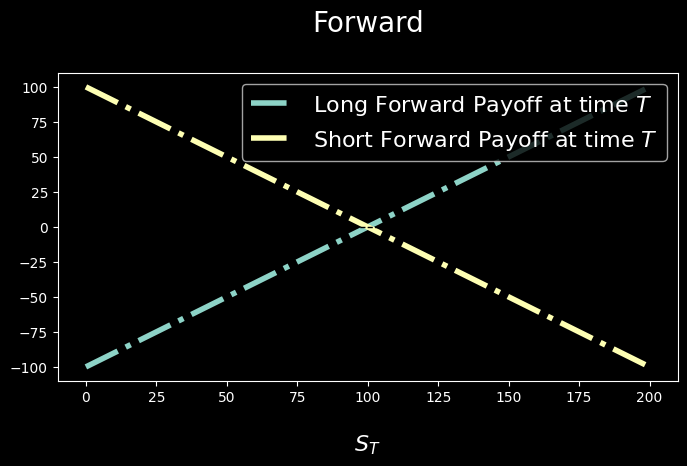

In [65]:
layout = {'title': 'Forward', 'x_label': '$S_{T}$', 'plot_type':['line'], 'linestyle': '-.','secondary_yaxis': [False, False]}
my_smart_plotter(x_stock_price, [y_forward_payoff, y_forward_payoff__short], layout=layout, names=['Long Forward Payoff at time $T$', 'Short Forward Payoff at time $T$'])

## HW 2/2: BSM pricer with Greeks

In [38]:
import numpy as np
from scipy.stats import norm

"""The pricing function of European call option"""
def black_scholes_eur_call(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray],
                           output: str = 'price') -> np.ndarray:
    """
    Black-Scholes pricer of European call option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param K: strike price (or prices)
    """
    # check conditions
    assert sigma > 0
    assert T > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5

    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)

    derN_d1 = norm.pdf(d1_vec)

    output = output.lower()
    if output == 'price':
        return N_d1_vec * S0 - K * np.exp((-1.0)*r*T) * N_d2_vec
    elif output == 'delta':
        return N_d1_vec
    elif output == 'vega':
        return S0 * derN_d1 * T**0.5
    elif output == 'theta':
        return (-S0 * derN_d1 * sigma / (2 * T**0.5)) - (r * K * np.exp((-1.0)*r*T) * N_d2_vec)
    elif output == 'rho':
        return K * T * np.exp((-1.0)*r*T) * N_d2_vec
    elif output == 'gamma':
        return derN_d1 / (S0 * sigma * T**0.5)
    else:
        raise ValueError(f"Invalid output type '{output}'."
                         "Choose from: 'price', 'delta', 'vega', 'theta', 'rho', 'gamma'.")

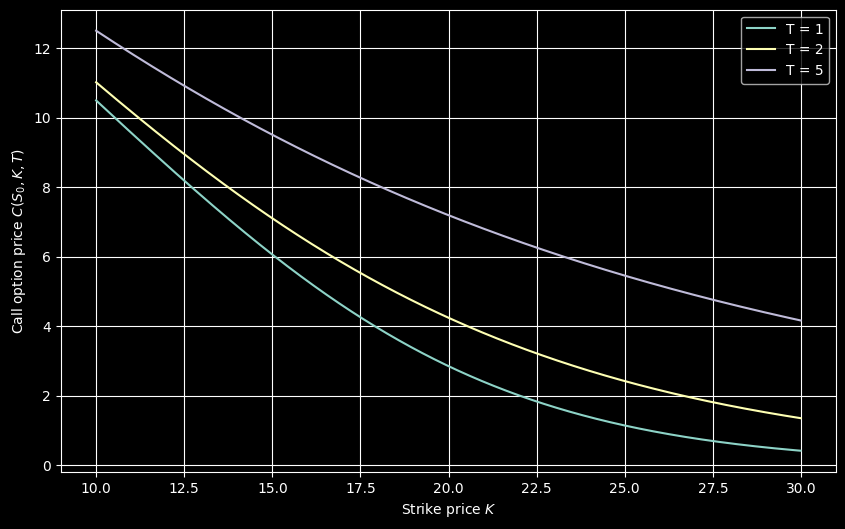

In [5]:
# Strike prices for which the option price is calculated
K_vec = np.arange(10, 30, 0.01)
# Time to maturities (in year fractions)
T_vec = [1.0, 2.0, 5.0]

prices_to_plot = []
for _T in T_vec:
    prices_to_plot.append(black_scholes_eur_call(r=0.05, T=_T, S0=20.0, sigma=0.3, K=K_vec, output='price'))

plt.figure(figsize=(10, 6))

for prices, T in zip(prices_to_plot, T_vec):
    plt.plot(K_vec, prices, label=f"T = {int(T)}")

plt.xlabel('Strike price $K$')
plt.ylabel('Call option price $C(S_0,K,T)$')

plt.legend()
plt.grid(True)
plt.show()

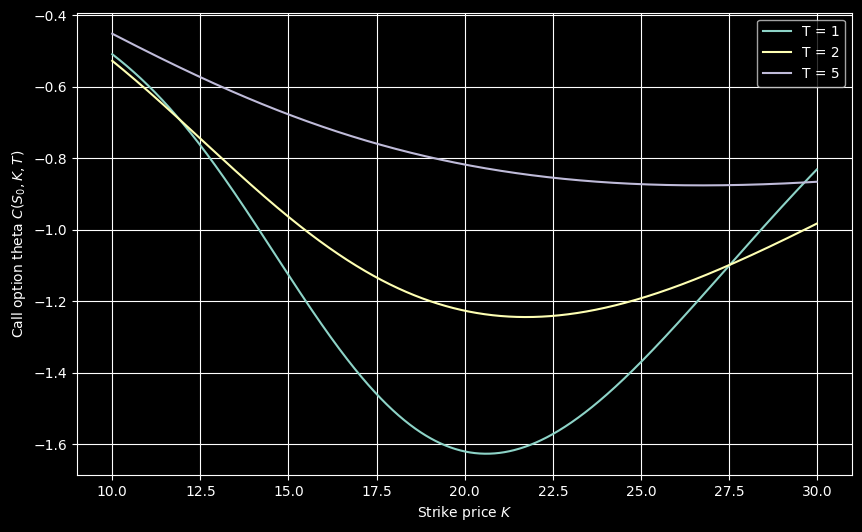

In [9]:
greek = 'theta'
greeks_to_plot = []
for _T in T_vec:
    greeks_to_plot.append(black_scholes_eur_call(r=0.05, T=_T, S0=20.0, sigma=0.3, K=K_vec, output=greek))

plt.figure(figsize=(10, 6))

for greeks, T in zip(greeks_to_plot, T_vec):
    plt.plot(K_vec, greeks, label=f"T = {int(T)}")

plt.xlabel('Strike price $K$')
plt.ylabel(f'Call option {greek} $C(S_0,K,T)$')

plt.legend()
plt.grid(True)
plt.show()

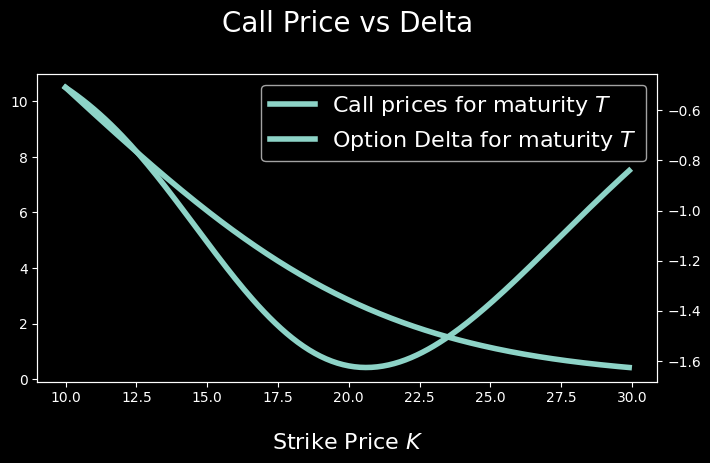

In [80]:
# Ez még a customized plotter-hez ábra. (Nem tudom miért nem használ különböző színeket. Próbáltam a függvénybe is beleírni, hogy a két görbe más színű legyen, de úgy is ugyanolyan lett :D)
K_vec = np.arange(10, 30, 0.1)
T = 1.0
S0 = 20
r = 0.05

call_prices = np.array(black_scholes_eur_call(r=r, T=T, S0=S0, sigma=0.3, K=K_vec, output='price'))
option_greek = np.array(black_scholes_eur_call(r=r, T=T, S0=S0, sigma=0.3, K=K_vec, output='theta'))

layout = {'title': 'Call Price vs Delta', 'x_label': 'Strike Price $K$', 'plot_type': ['line', 'scatter'],
          'linestyle': '-','scatter_marker': '^','secondary_yaxis': [False, True]}
my_smart_plotter(K_vec, [call_prices, option_greek], layout=layout, names=['Call prices for maturity $T$', 'Option Delta for maturity $T$'])

## HW 2/3: BSM pricer for put options

In [11]:
"""The pricing function of European put option"""
def black_scholes_eur_put(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray],
                           output: str = 'price') -> np.ndarray:
    """
    Black-Scholes pricer of European put option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param K: strike price (or prices)
    """
    # check conditions
    assert sigma > 0
    assert T > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5

    N_d1_vec = norm.cdf(-d1_vec)
    N_d2_vec = norm.cdf(-d2_vec)

    derN_d1 = norm.pdf(d1_vec)

    output = output.lower()
    if output == 'price':
        return K * np.exp((-1.0)*r*T) * N_d2_vec - S0 * N_d1_vec
    elif output == 'delta':
        return (-1.0) * N_d1_vec
    elif output == 'vega':
        return S0 * derN_d1 * T**0.5
    elif output == 'theta':
        return (-S0 * derN_d1 * sigma / (2 * T**0.5)) + (r * K * np.exp((-1.0)*r*T) * N_d2_vec)
    elif output == 'rho':
        return -K * T * np.exp((-1.0)*r*T) * N_d2_vec
    elif output == 'gamma':
        return derN_d1 / (S0 * sigma * T**0.5)
    else:
        raise ValueError(f"Invalid output type '{output}'."
                         "Choose from: 'price', 'delta', 'vega', 'theta', 'rho', 'gamma'.")

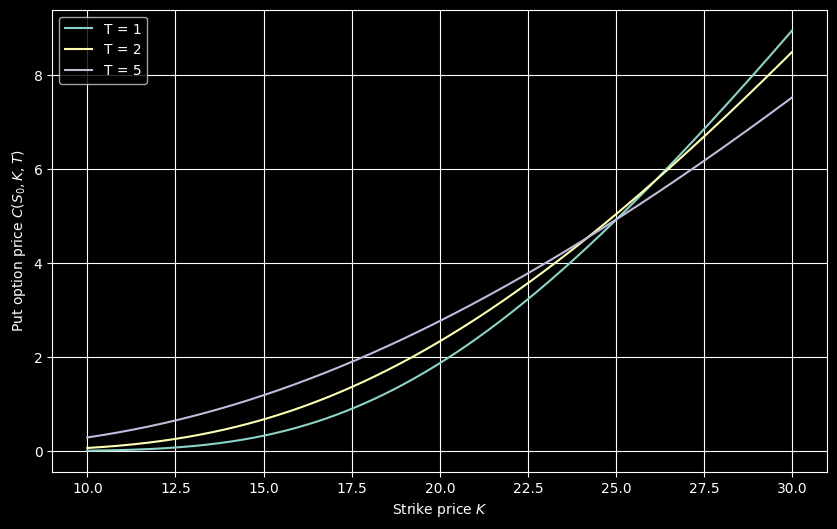

In [12]:
# Strike prices for which the option price is calculated
K_vec = np.arange(10, 30, 0.01)
# Time to maturities (in year fractions)
T_vec = [1.0, 2.0, 5.0]

put_prices_to_plot = []
for _T in T_vec:
    put_prices_to_plot.append(black_scholes_eur_put(r=0.05, T=_T, S0=20.0, sigma=0.3, K=K_vec, output='price'))

plt.figure(figsize=(10, 6))

for prices, T in zip(put_prices_to_plot, T_vec):
    plt.plot(K_vec, prices, label=f"T = {int(T)}")

plt.xlabel('Strike price $K$')
plt.ylabel('Put option price $C(S_0,K,T)$')

plt.legend()
plt.grid(True)
plt.show()

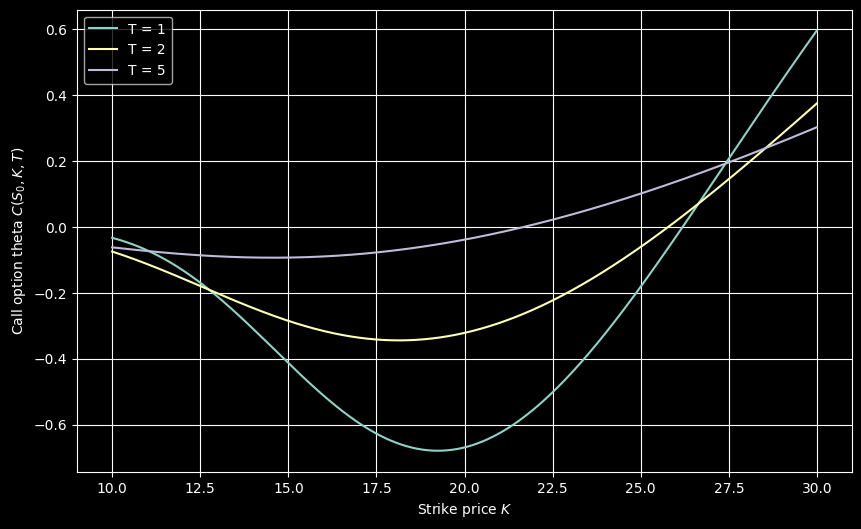

In [14]:
put_greek = 'theta'
put_greeks_to_plot = []
for _T in T_vec:
    put_greeks_to_plot.append(black_scholes_eur_put(r=0.05, T=_T, S0=20.0, sigma=0.3, K=K_vec, output=put_greek))

plt.figure(figsize=(10, 6))

for greeks, T in zip(put_greeks_to_plot, T_vec):
    plt.plot(K_vec, greeks, label=f"T = {int(T)}")

plt.xlabel('Strike price $K$')
plt.ylabel(f'Call option {greek} $C(S_0,K,T)$')

plt.legend()
plt.grid(True)
plt.show()

## HW 2/4: Put-Call parity check

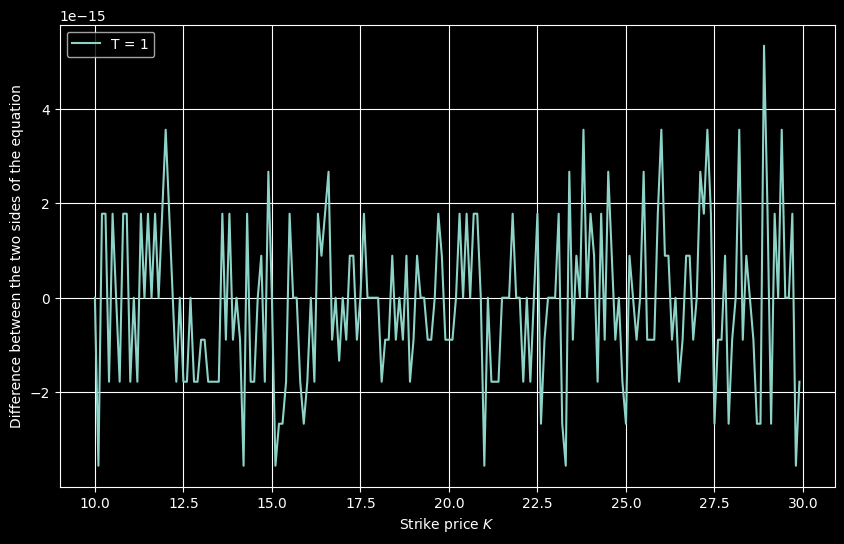

In [37]:
K_vec = np.arange(10, 30, 0.1)
T_vec = [1.0]
S0 = 20.0
r = 0.05

diff_to_plot= []
for _T in T_vec:
    call = black_scholes_eur_call(r=0.05, T=_T, S0=20.0, sigma=0.3, K=K_vec, output='price')
    put = black_scholes_eur_put(r=0.05, T=_T, S0=20.0, sigma=0.3, K=K_vec, output='price')
    left_side = call - put
    right_side = S0 - K_vec * np.exp((-1.0)*r*_T)
    diff_to_plot.append(left_side - right_side)

plt.figure(figsize=(10, 6))

for diffs, T in zip(diff_to_plot, T_vec):
    plt.plot(K_vec, diffs, label=f"T = {int(T)}")

plt.xlabel('Strike price $K$')
plt.ylabel('Difference between the two sides of the equation')

plt.legend()
plt.grid(True)
plt.show()

Egyenlet két fele közötti eltérés elhanyagolható nagyságú (pl.: 2*10^-15), szóval vehetjük úgy, hogy a put-call parity fenn áll.

###